## Looking to see how points change during certain situations

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
s20 = pd.read_parquet("/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2019-20/regular_season/player_gamelogs.parquet")
s21 = pd.read_parquet("/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2020-21/regular_season/player_gamelogs.parquet")
s22 = pd.read_parquet("/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2021-22/regular_season/player_gamelogs.parquet")
s23 = pd.read_parquet("/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2022-23/regular_season/player_gamelogs.parquet")
s24 = pd.read_parquet("/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2023-24/regular_season/player_gamelogs.parquet")
s25 = pd.read_parquet("/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2024-25/regular_season/player_gamelogs.parquet")
s26 = pd.read_parquet("/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2025-26/regular_season/player_gamelogs.parquet")
df = pd.concat([s20, s21, s22, s23, s24, s25, s26])
print(f"Number of rows: {len(df)}")
print(f"Number of columns: {len(df.columns)}")
df.sample(5)

Number of rows: 176738
Number of columns: 189


,season_year,player_id,player_name,nickname,team_id,team_abbreviation,team_name,game_id,game_date,matchup,...,opp_e_pace,opp_pace,opp_pace_per40,opp_poss,opp_pie,season_type,pos,game_total,team_spread,player_team_spread
11137,2021-22,1630166,Deni Avdija,Deni,1610612764,WAS,Washington Wizards,0022100699,2022-01-23T00:00:00,WAS vs. BOS,...,99.6,97.0,80.83,97,0.614,Regular Season,SF,216.5,2.5,2.5
10494,2024-25,1628983,Shai Gilgeous-Alexander,Shai,1610612760,OKC,Oklahoma City Thunder,0022400705,2025-02-03T00:00:00,OKC vs. MIL,...,106.9,104.5,87.08,104,0.362,Regular Season,PG,226.5,-17.5,-17.5
23244,2022-23,200752,Rudy Gay,Rudy,1610612762,UTA,Utah Jazz,0022200131,2022-11-04T00:00:00,UTA @ LAL,...,98.9,96.5,80.42,96,0.457,Regular Season,PF,229.0,-3.5,3.5
1358,2025-26,1642883,Sion James,Sion,1610612766,CHA,Charlotte Hornets,0022501137,2026-04-05T00:00:00,CHA @ MIN,...,97.9,97.5,81.25,97,0.433,Regular Season,SG,225.5,-1.5,1.5
8611,2019-20,201565,Derrick Rose,Derrick,1610612765,DET,Detroit Pistons,0021900639,2020-01-20T00:00:00,DET @ WAS,...,103.4,102.0,85.00,103,0.559,Regular Season,PG,232.5,-1.0,1.0


In [30]:
# Helpers
starter = df["start_position"].astype("string").str.strip()
df["starting"] = starter.isin(["G", "F", "C"]).astype(int)
df["starting"].value_counts(dropna=False)

starting
0    93848
1    82890
Name: count, dtype: int64

In [31]:
starting = df[df["starting"] == 1]
bench = df[df["starting"] == 0]
pd.concat(
    {
        "starting": starting["pts"].describe(),
        "bench": bench["pts"].describe(),
    },
    axis=1,
)


,starting,bench
count,82890.000000,93848.000000
mean,15.496803,6.329192
std,8.960514,5.845225
min,0.000000,0.000000
25%,9.000000,2.000000
50%,14.000000,5.000000
75%,21.000000,10.000000
max,83.000000,50.000000


### First we will look at starters

In [32]:
starter_points_by_slot = starting.groupby(
    starting["start_position"].astype("string").str.strip(),
    dropna=False,
)["pts"].describe().T
starter_points_by_pos = starting.groupby("pos", dropna=False)["pts"].describe().T

starter_points_by_slot = starter_points_by_slot.reindex(
    columns=["G", "F", "C"],
)
starter_points_by_pos = starter_points_by_pos.reindex(
    columns=["PG", "SG", "SF", "PF", "C"],
)

display(starter_points_by_slot)
display(starter_points_by_pos)

start_position,G,F,C
count,33156.000000,33156.000000,16578.000000
mean,16.922578,15.006907,13.625045
std,9.365451,8.677707,8.208867
min,0.000000,0.000000,0.000000
25%,10.000000,8.000000,8.000000
50%,16.000000,14.000000,12.000000
75%,23.000000,20.000000,18.000000
max,73.000000,64.000000,83.000000


pos,PG,SG,SF,PF,C
count,15619.000000,18099.000000,15971.000000,16397.000000,16796.000000
mean,17.783725,15.722692,15.004195,15.312801,13.777804
std,9.749223,8.970110,8.483498,8.846819,8.256208
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,10.000000,9.000000,9.000000,9.000000,8.000000
50%,17.000000,15.000000,14.000000,14.000000,13.000000
75%,24.000000,21.000000,20.000000,21.000000,18.000000
max,73.000000,71.000000,60.000000,64.000000,83.000000


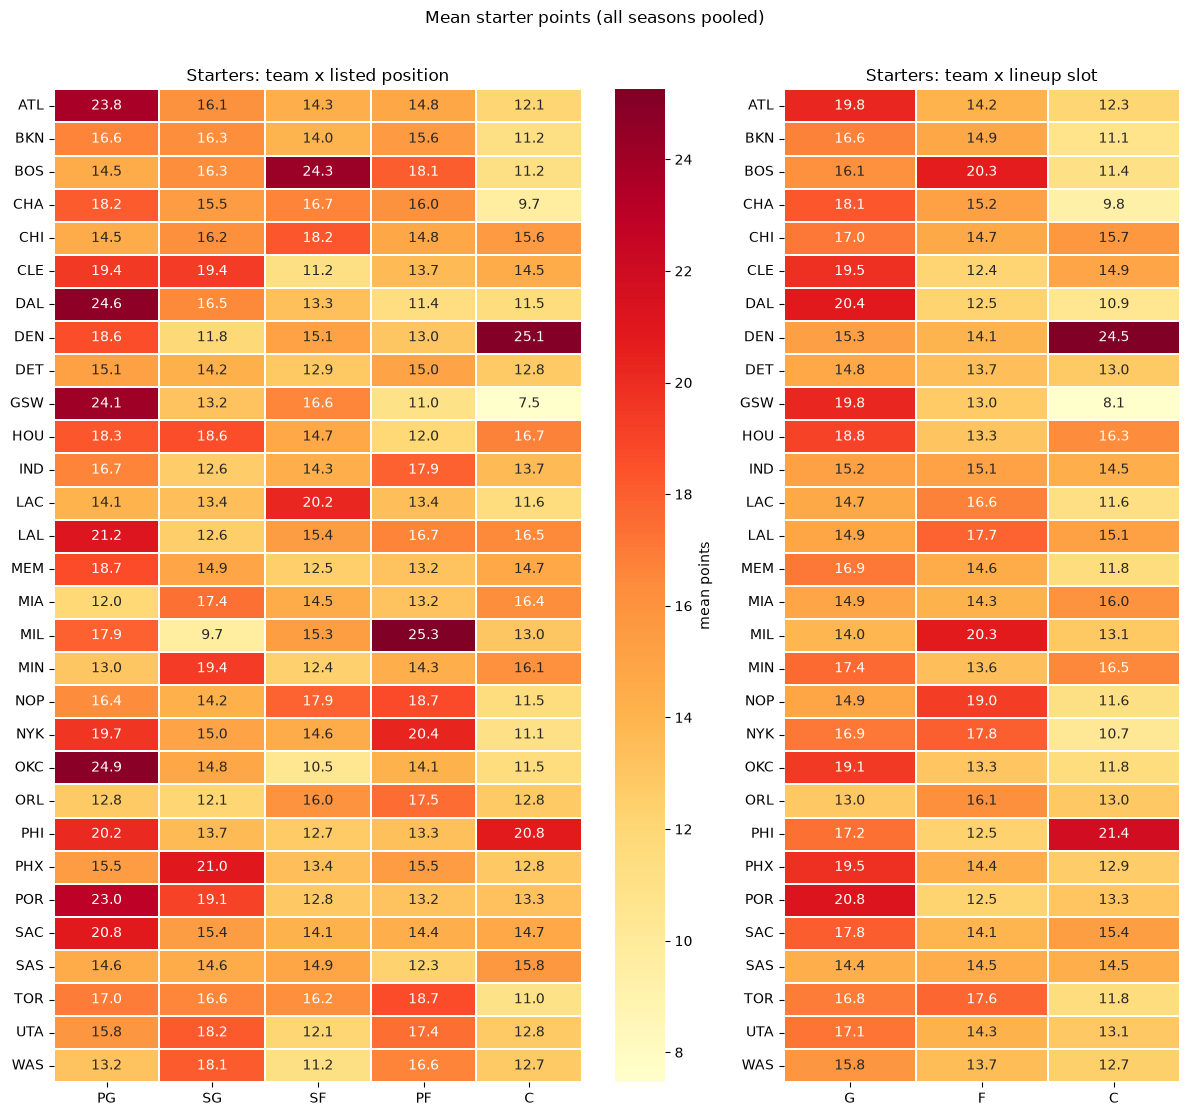

In [33]:
pos_order = ["PG", "SG", "SF", "PF", "C"]
slot_order = ["G", "F", "C"]

starter_pos = starting.assign(
    pos=starting["pos"].astype("string"),
    start_slot=starting["start_position"].astype("string").str.strip(),
)

points_by_team_pos = (
    starter_pos.loc[starter_pos["pos"].isin(pos_order)]
    .groupby(["team_abbreviation", "pos"], observed=False)["pts"]
    .mean()
    .unstack("pos")
    .reindex(columns=pos_order)
    .sort_index()
)
points_by_team_slot = (
    starter_pos.loc[starter_pos["start_slot"].isin(slot_order)]
    .groupby(["team_abbreviation", "start_slot"], observed=False)["pts"]
    .mean()
    .unstack("start_slot")
    .reindex(columns=slot_order)
    .sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 11), gridspec_kw={"width_ratios": [5, 3]})
sns.heatmap(
    points_by_team_pos,
    ax=axes[0],
    cmap="YlOrRd",
    annot=True,
    fmt=".1f",
    linewidths=0.3,
    cbar_kws={"label": "mean points"},
)
axes[0].set_title("Starters: team x listed position")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

sns.heatmap(
    points_by_team_slot,
    ax=axes[1],
    cmap="YlOrRd",
    annot=True,
    fmt=".1f",
    linewidths=0.3,
    cbar=False,
)
axes[1].set_title("Starters: team x lineup slot")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
fig.suptitle("Mean starter points (all seasons pooled)", y=1.01)
plt.tight_layout()
plt.show()

inference:


spread_role,≤ -7.5,-7.5 to -3,-3 to 3.5,> 3.5
pos,,,,
PG,19.20,18.87,18.02,16.07
SG,15.99,15.89,16.04,15.24
SF,15.88,15.34,14.93,14.37
PF,16.43,15.73,15.34,14.50
C,14.90,14.63,13.55,12.81


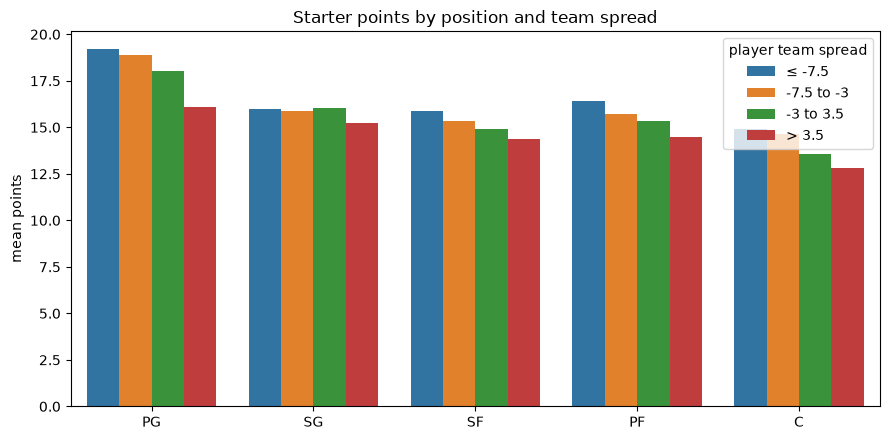

In [34]:
pos_order = ["PG", "SG", "SF", "PF", "C"]
spread_order = ["≤ -7.5", "-7.5 to -3", "-3 to 3.5", "> 3.5"]
spread = pd.to_numeric(starting["player_team_spread"], errors="coerce")
starter_script = starting.assign(
    pos=starting["pos"].astype("string"),
    spread_role=pd.cut(
        spread,
        bins=[-np.inf, -7.5, -3, 3.5, np.inf],
        labels=spread_order,
        right=True,
    ).astype("string"),
)
starter_script = starter_script.loc[
    starter_script["pos"].isin(pos_order)
    & starter_script["spread_role"].isin(spread_order)
]

points_by_pos_script = (
    starter_script.groupby(["pos", "spread_role"], observed=False)["pts"]
    .agg(mean="mean", median="median", rows="size")
    .reset_index()
)
means = (
    points_by_pos_script.pivot(index="pos", columns="spread_role", values="mean")
    .reindex(index=pos_order, columns=spread_order)
)
display(means.round(2))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(
    data=points_by_pos_script,
    x="pos",
    y="mean",
    hue="spread_role",
    order=pos_order,
    hue_order=spread_order,
    ax=ax,
)
ax.set_title("Starter points by position and team spread")
ax.set_xlabel("")
ax.set_ylabel("mean points")
ax.legend(title="player team spread")
plt.tight_layout()
plt.show()


total_band,≤ 221,221–227,227.5–233.5,≥ 234
pos,,,,
PG,16.01,17.65,18.54,19.72
SG,15.18,15.60,16.04,16.22
SF,14.56,15.22,15.28,15.10
PF,14.79,15.05,15.43,16.47
C,13.10,13.59,14.00,14.80


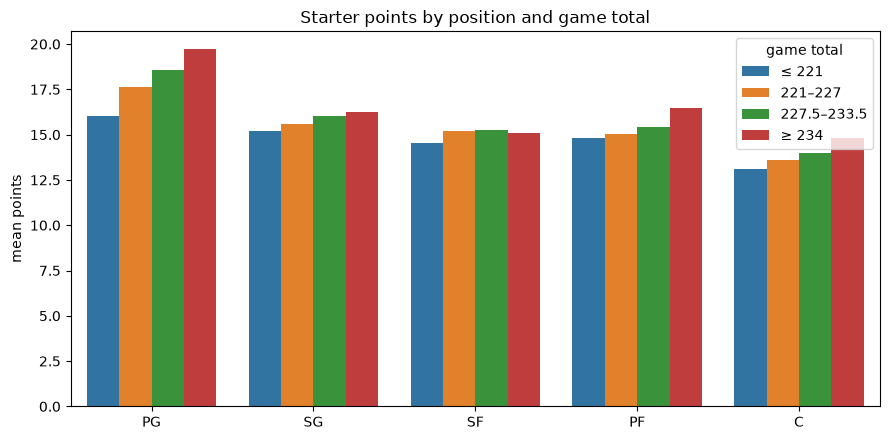

In [35]:
pos_order = ["PG", "SG", "SF", "PF", "C"]
total_order = ["≤ 221", "221–227", "227.5–233.5", "≥ 234"]
game_total = pd.to_numeric(starting["game_total"], errors="coerce")
starter_total = starting.assign(
    pos=starting["pos"].astype("string"),
    total_band=pd.cut(
        game_total,
        bins=[-np.inf, 221, 227, 233.5, np.inf],
        labels=total_order,
        right=True,
    ).astype("string"),
)
starter_total = starter_total.loc[
    starter_total["pos"].isin(pos_order)
    & starter_total["total_band"].isin(total_order)
]

points_by_pos_total = (
    starter_total.groupby(["pos", "total_band"], observed=False)["pts"]
    .agg(mean="mean", median="median", rows="size")
    .reset_index()
)
means = (
    points_by_pos_total.pivot(index="pos", columns="total_band", values="mean")
    .reindex(index=pos_order, columns=total_order)
)
display(means.round(2))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(
    data=points_by_pos_total,
    x="pos",
    y="mean",
    hue="total_band",
    order=pos_order,
    hue_order=total_order,
    ax=ax,
)
ax.set_title("Starter points by position and game total")
ax.set_xlabel("")
ax.set_ylabel("mean points")
ax.legend(title="game total")
plt.tight_layout()
plt.show()


rest_band,B2B,2,3,3+
pos,,,,
PG,17.64,17.70,18.21,18.01
SG,15.52,15.73,15.73,16.02
SF,14.44,15.05,15.31,15.30
PF,14.76,15.38,15.54,15.42
C,13.61,13.78,14.02,13.77


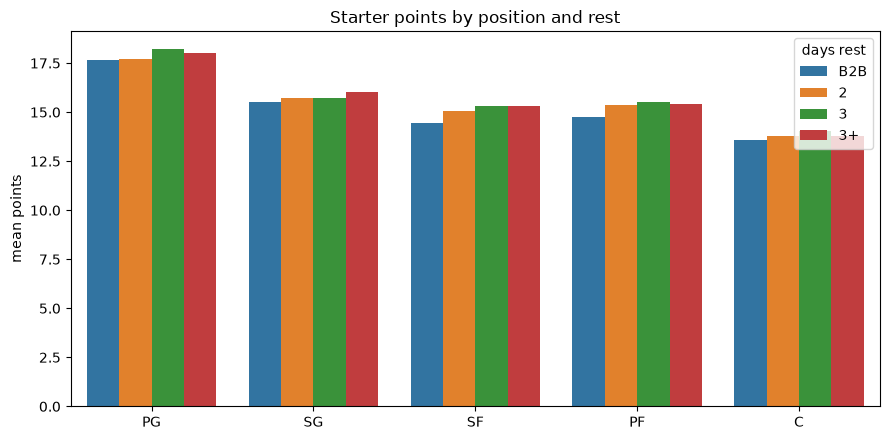

In [36]:
pos_order = ["PG", "SG", "SF", "PF", "C"]
rest_order = ["B2B", "2", "3", "3+"]

rest = df.copy()
rest["game_date"] = pd.to_datetime(rest["game_date"])
rest = rest.sort_values(["player_id", "season_year", "game_date"], kind="stable")
rest["days_rest"] = (
    rest.groupby(["player_id", "season_year"], sort=False)["game_date"]
    .diff()
    .dt.days
)
rest["rest_band"] = np.select(
    [
        rest["days_rest"].eq(1),
        rest["days_rest"].eq(2),
        rest["days_rest"].eq(3),
        rest["days_rest"].ge(4),
    ],
    rest_order,
    default="other",
)

starter_rest = rest.loc[rest["starting"].eq(1)].assign(
    pos=lambda frame: frame["pos"].astype("string"),
)
starter_rest = starter_rest.loc[
    starter_rest["pos"].isin(pos_order)
    & starter_rest["rest_band"].isin(rest_order)
]

points_by_pos_rest = (
    starter_rest.groupby(["pos", "rest_band"], observed=False)["pts"]
    .agg(mean="mean", median="median", rows="size")
    .reset_index()
)
means = (
    points_by_pos_rest.pivot(index="pos", columns="rest_band", values="mean")
    .reindex(index=pos_order, columns=rest_order)
)
display(means.round(2))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(
    data=points_by_pos_rest,
    x="pos",
    y="mean",
    hue="rest_band",
    order=pos_order,
    hue_order=rest_order,
    ax=ax,
)
ax.set_title("Starter points by position and rest")
ax.set_xlabel("")
ax.set_ylabel("mean points")
ax.legend(title="days rest")
plt.tight_layout()
plt.show()

rest_band,B2B,2,3,3+
season_year,,,,
2019-20,14.28,14.88,15.17,15.14
2020-21,14.89,15.22,15.66,15.32
2021-22,14.77,15.17,14.90,15.50
2022-23,15.74,15.97,16.24,16.34
2023-24,15.62,15.98,16.14,16.24
2024-25,15.42,15.62,15.98,15.93
2025-26,15.28,15.61,15.94,15.14


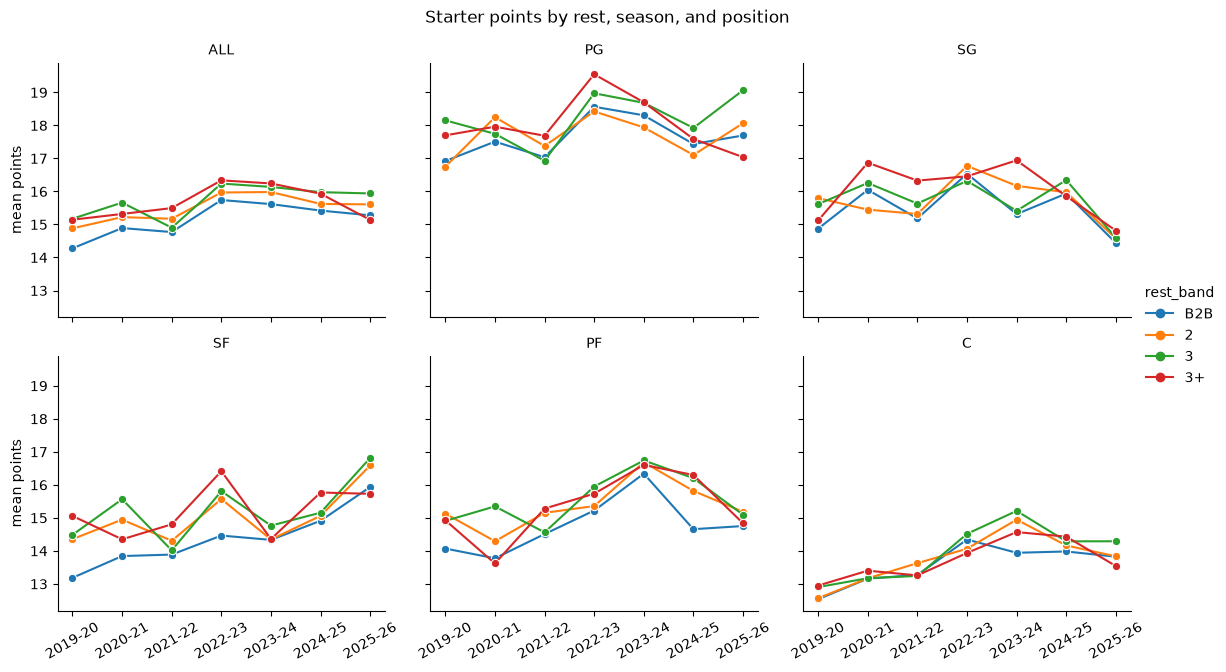

In [37]:
season_order = ["2019-20", "2020-21", "2021-22", "2022-23", "2023-24", "2024-25", "2025-26"]
starter_rest_year = starter_rest.assign(
    season_year=starter_rest["season_year"].astype("string"),
)
starter_rest_year = starter_rest_year.loc[
    starter_rest_year["season_year"].isin(season_order)
]

points_by_year_rest = (
    starter_rest_year.groupby(
        ["season_year", "pos", "rest_band"],
        observed=False,
    )["pts"]
    .mean()
    .reset_index(name="mean")
)
overall_by_year_rest = (
    starter_rest_year.groupby(["season_year", "rest_band"], observed=False)["pts"]
    .mean()
    .reset_index(name="mean")
    .assign(pos="ALL")
)
means = (
    overall_by_year_rest.pivot(index="season_year", columns="rest_band", values="mean")
    .reindex(index=season_order, columns=rest_order)
)
display(means.round(2))

plot = pd.concat([overall_by_year_rest, points_by_year_rest], ignore_index=True)
figure = sns.relplot(
    data=plot,
    x="season_year",
    y="mean",
    hue="rest_band",
    hue_order=rest_order,
    col="pos",
    col_order=["ALL", *pos_order],
    col_wrap=3,
    kind="line",
    marker="o",
    height=3.2,
    aspect=1.2,
)
figure.set_axis_labels("", "mean points")
figure.set_titles("{col_name}")
figure.figure.suptitle(
    "Starter points by rest, season, and position",
    y=1.03,
)
for ax in figure.axes.flatten():
    ax.tick_params(axis="x", rotation=30)
plt.show()


season_phase,before All-Star,after All-Star
pos,,
PG,17.96,17.46
SG,15.67,15.81
SF,14.95,15.12
PF,15.43,15.06
C,13.71,13.94


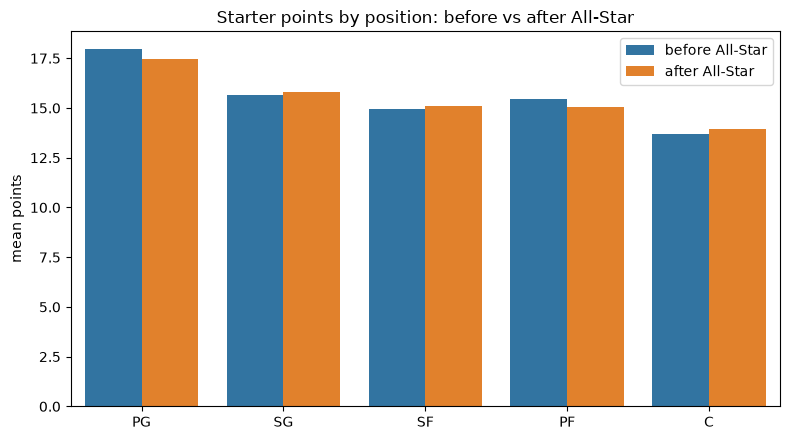

season_phase,before All-Star,after All-Star
rest_band,,
B2B,15.13,15.25
2,15.54,15.44
3,15.70,15.82
3+,15.77,15.53


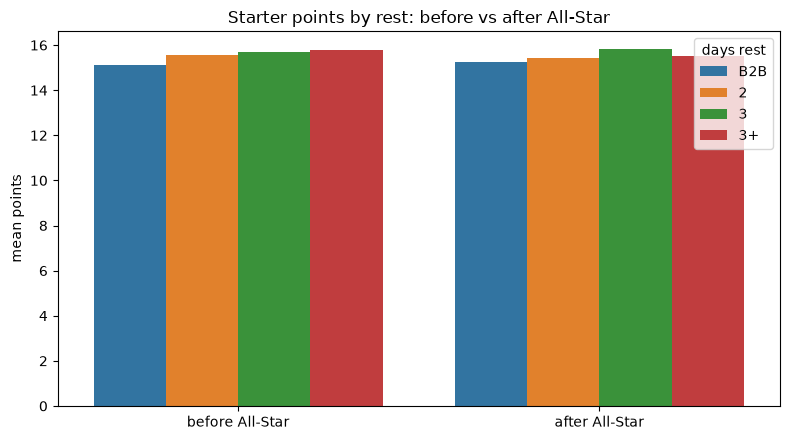

In [38]:
phase_order = ["before All-Star", "after All-Star"]
ALL_STAR_DATES = {
    "2019-20": pd.Timestamp("2020-02-16"),
    "2020-21": pd.Timestamp("2021-03-07"),
    "2021-22": pd.Timestamp("2022-02-20"),
    "2022-23": pd.Timestamp("2023-02-19"),
    "2023-24": pd.Timestamp("2024-02-18"),
    "2024-25": pd.Timestamp("2025-02-16"),
    "2025-26": pd.Timestamp("2026-02-15"),
}
game_date = pd.to_datetime(starter_rest["game_date"])
asb = starter_rest["season_year"].map(ALL_STAR_DATES)
starter_phase = starter_rest.assign(
    season_phase=np.select(
        [game_date.lt(asb), game_date.gt(asb)],
        phase_order,
        default="other",
    ),
)
starter_phase = starter_phase.loc[
    starter_phase["season_phase"].isin(phase_order)
]

points_by_pos_phase = (
    starter_phase.groupby(["pos", "season_phase"], observed=False)["pts"]
    .agg(mean="mean", median="median", rows="size")
    .reset_index()
)
means_phase = (
    points_by_pos_phase.pivot(index="pos", columns="season_phase", values="mean")
    .reindex(index=pos_order, columns=phase_order)
)
display(means_phase.round(2))

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(
    data=points_by_pos_phase,
    x="pos",
    y="mean",
    hue="season_phase",
    order=pos_order,
    hue_order=phase_order,
    ax=ax,
)
ax.set_title("Starter points by position: before vs after All-Star")
ax.set_xlabel("")
ax.set_ylabel("mean points")
ax.legend(title="")
plt.tight_layout()
plt.show()

points_by_rest_phase = (
    starter_phase.groupby(["rest_band", "season_phase"], observed=False)["pts"]
    .mean()
    .reset_index(name="mean")
)
means_rest_phase = (
    points_by_rest_phase.pivot(index="rest_band", columns="season_phase", values="mean")
    .reindex(index=rest_order, columns=phase_order)
)
display(means_rest_phase.round(2))

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(
    data=points_by_rest_phase,
    x="season_phase",
    y="mean",
    hue="rest_band",
    order=phase_order,
    hue_order=rest_order,
    ax=ax,
)
ax.set_title("Starter points by rest: before vs after All-Star")
ax.set_xlabel("")
ax.set_ylabel("mean points")
ax.legend(title="days rest")
plt.tight_layout()
plt.show()


### Now we'll explore bench players

In [39]:
pos_order = ["PG", "SG", "SF", "PF", "C"]
bench_points_by_pos = (
    bench.groupby("pos", dropna=False)["pts"]
    .describe()
    .T
    .reindex(columns=pos_order)
)
display(bench_points_by_pos)


pos,PG,SG,SF,PF,C
count,15859.000000,25183.000000,17206.000000,18068.000000,17326.000000
mean,6.648528,6.956320,6.013193,6.007970,5.776059
std,6.025866,6.389155,5.760138,5.506055,5.145340
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,2.000000,2.000000,2.000000
50%,5.000000,6.000000,5.000000,5.000000,5.000000
75%,10.000000,11.000000,9.000000,9.000000,9.000000
max,50.000000,45.000000,43.000000,43.000000,35.000000


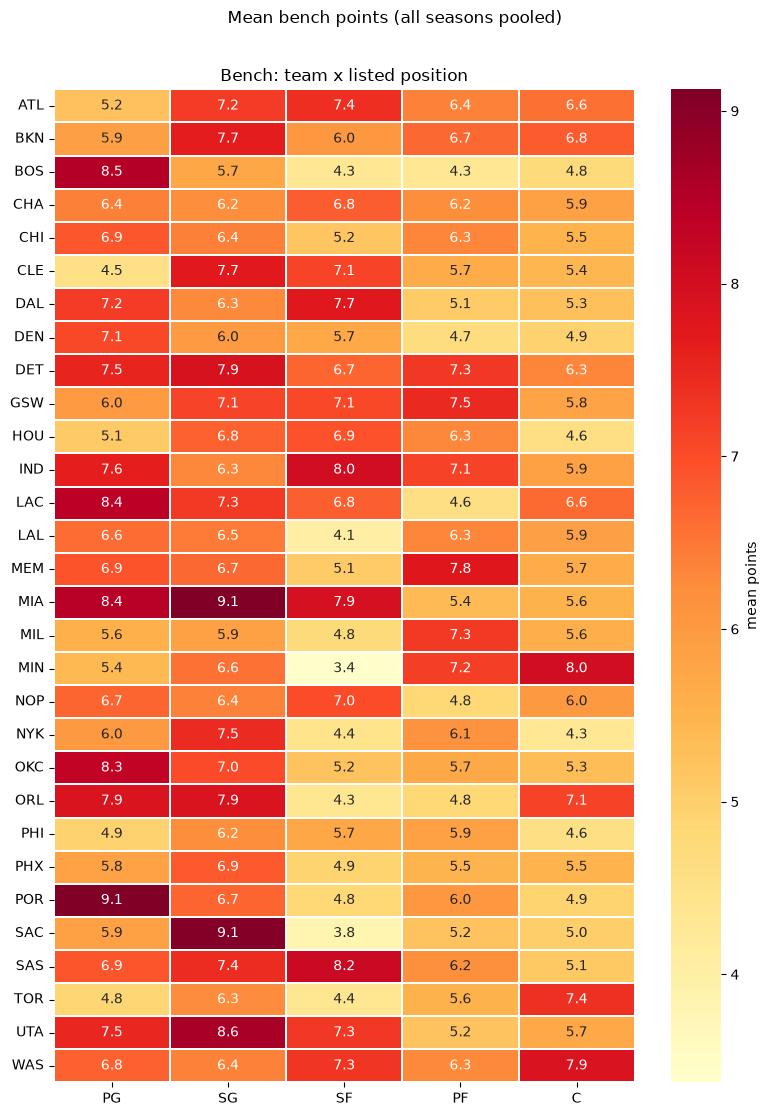

In [40]:
pos_order = ["PG", "SG", "SF", "PF", "C"]
bench_pos = bench.assign(pos=bench["pos"].astype("string"))
points_by_team_pos = (
    bench_pos.loc[bench_pos["pos"].isin(pos_order)]
    .groupby(["team_abbreviation", "pos"], observed=False)["pts"]
    .mean()
    .unstack("pos")
    .reindex(columns=pos_order)
    .sort_index()
)

fig, ax = plt.subplots(figsize=(8, 11))
sns.heatmap(
    points_by_team_pos,
    ax=ax,
    cmap="YlOrRd",
    annot=True,
    fmt=".1f",
    linewidths=0.3,
    cbar_kws={"label": "mean points"},
)
ax.set_title("Bench: team x listed position")
ax.set_xlabel("")
ax.set_ylabel("")
fig.suptitle("Mean bench points (all seasons pooled)", y=1.01)
plt.tight_layout()
plt.show()


spread_role,≤ -7.5,-7.5 to -3,-3 to 3.5,> 3.5
pos,,,,
PG,6.23,6.45,6.48,7.09
SG,6.78,6.95,6.86,7.12
SF,5.53,5.73,5.81,6.55
PF,5.67,5.85,5.90,6.39
C,5.79,5.59,5.57,6.04


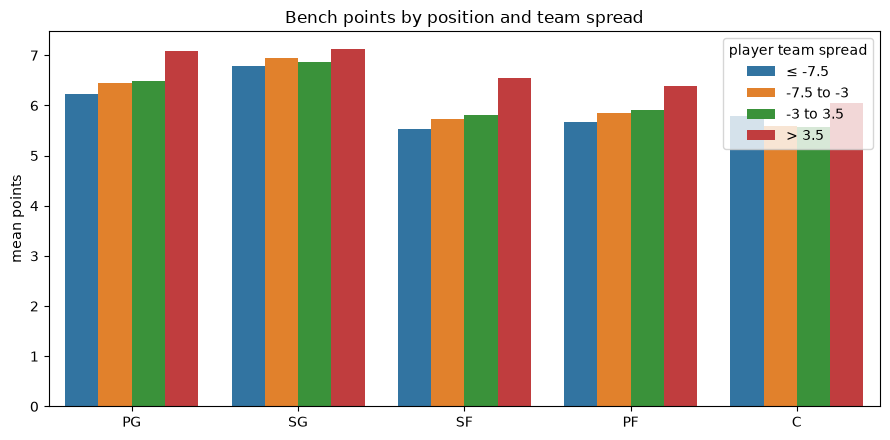

In [41]:
pos_order = ["PG", "SG", "SF", "PF", "C"]
spread_order = ["≤ -7.5", "-7.5 to -3", "-3 to 3.5", "> 3.5"]
spread = pd.to_numeric(bench["player_team_spread"], errors="coerce")
bench_script = bench.assign(
    pos=bench["pos"].astype("string"),
    spread_role=pd.cut(
        spread,
        bins=[-np.inf, -7.5, -3, 3.5, np.inf],
        labels=spread_order,
        right=True,
    ).astype("string"),
)
bench_script = bench_script.loc[
    bench_script["pos"].isin(pos_order)
    & bench_script["spread_role"].isin(spread_order)
]

points_by_pos_script = (
    bench_script.groupby(["pos", "spread_role"], observed=False)["pts"]
    .agg(mean="mean", median="median", rows="size")
    .reset_index()
)
means = (
    points_by_pos_script.pivot(index="pos", columns="spread_role", values="mean")
    .reindex(index=pos_order, columns=spread_order)
)
display(means.round(2))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(
    data=points_by_pos_script,
    x="pos",
    y="mean",
    hue="spread_role",
    order=pos_order,
    hue_order=spread_order,
    ax=ax,
)
ax.set_title("Bench points by position and team spread")
ax.set_xlabel("")
ax.set_ylabel("mean points")
ax.legend(title="player team spread")
plt.tight_layout()
plt.show()


total_band,≤ 221,221–227,227.5–233.5,≥ 234
pos,,,,
PG,6.57,6.63,6.71,6.64
SG,6.86,6.90,6.93,7.14
SF,5.61,5.89,6.00,6.71
PF,5.89,6.04,5.99,6.11
C,5.75,5.71,5.71,5.96


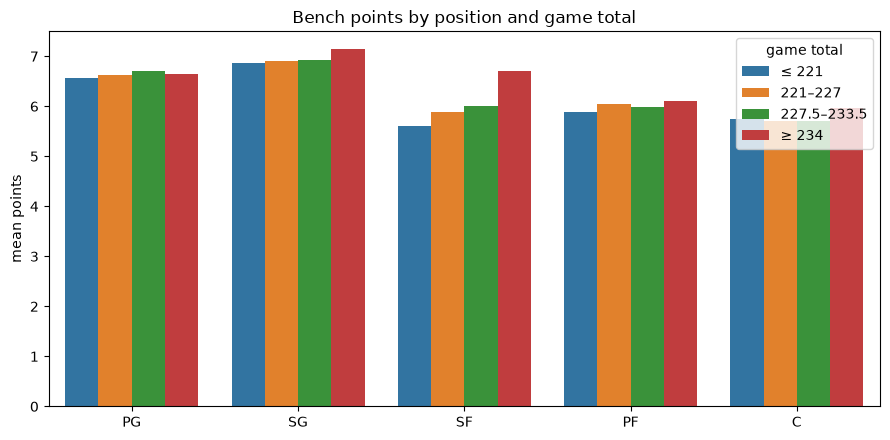

In [42]:
pos_order = ["PG", "SG", "SF", "PF", "C"]
total_order = ["≤ 221", "221–227", "227.5–233.5", "≥ 234"]
game_total = pd.to_numeric(bench["game_total"], errors="coerce")
bench_total = bench.assign(
    pos=bench["pos"].astype("string"),
    total_band=pd.cut(
        game_total,
        bins=[-np.inf, 221, 227, 233.5, np.inf],
        labels=total_order,
        right=True,
    ).astype("string"),
)
bench_total = bench_total.loc[
    bench_total["pos"].isin(pos_order)
    & bench_total["total_band"].isin(total_order)
]

points_by_pos_total = (
    bench_total.groupby(["pos", "total_band"], observed=False)["pts"]
    .agg(mean="mean", median="median", rows="size")
    .reset_index()
)
means = (
    points_by_pos_total.pivot(index="pos", columns="total_band", values="mean")
    .reindex(index=pos_order, columns=total_order)
)
display(means.round(2))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(
    data=points_by_pos_total,
    x="pos",
    y="mean",
    hue="total_band",
    order=pos_order,
    hue_order=total_order,
    ax=ax,
)
ax.set_title("Bench points by position and game total")
ax.set_xlabel("")
ax.set_ylabel("mean points")
ax.legend(title="game total")
plt.tight_layout()
plt.show()


rest_band,B2B,2,3,3+
pos,,,,
PG,7.49,7.22,6.53,4.80
SG,7.70,7.58,7.23,4.91
SF,6.83,6.61,6.32,4.08
PF,6.60,6.60,6.20,4.21
C,6.56,6.28,5.96,4.16


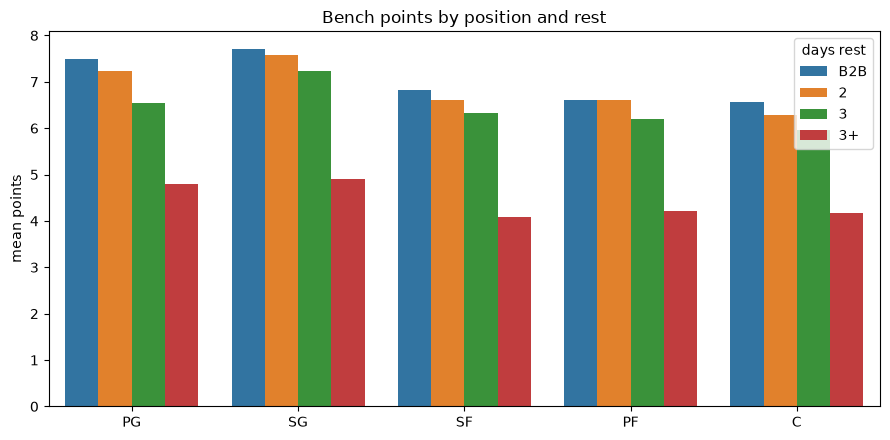

In [43]:
pos_order = ["PG", "SG", "SF", "PF", "C"]
rest_order = ["B2B", "2", "3", "3+"]
bench_rest = rest.loc[rest["starting"].eq(0)].assign(
    pos=lambda frame: frame["pos"].astype("string"),
)
bench_rest = bench_rest.loc[
    bench_rest["pos"].isin(pos_order)
    & bench_rest["rest_band"].isin(rest_order)
]

points_by_pos_rest = (
    bench_rest.groupby(["pos", "rest_band"], observed=False)["pts"]
    .agg(mean="mean", median="median", rows="size")
    .reset_index()
)
means = (
    points_by_pos_rest.pivot(index="pos", columns="rest_band", values="mean")
    .reindex(index=pos_order, columns=rest_order)
)
display(means.round(2))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(
    data=points_by_pos_rest,
    x="pos",
    y="mean",
    hue="rest_band",
    order=pos_order,
    hue_order=rest_order,
    ax=ax,
)
ax.set_title("Bench points by position and rest")
ax.set_xlabel("")
ax.set_ylabel("mean points")
ax.legend(title="days rest")
plt.tight_layout()
plt.show()


rest_band,B2B,2,3,3+
season_year,,,,
2019-20,7.54,7.35,6.79,4.63
2020-21,7.18,6.95,6.19,4.18
2021-22,7.11,6.86,6.35,4.56
2022-23,7.00,6.79,6.77,4.41
2023-24,6.65,6.65,6.39,4.18
2024-25,6.89,6.97,6.23,4.38
2025-26,7.33,6.89,6.78,4.82


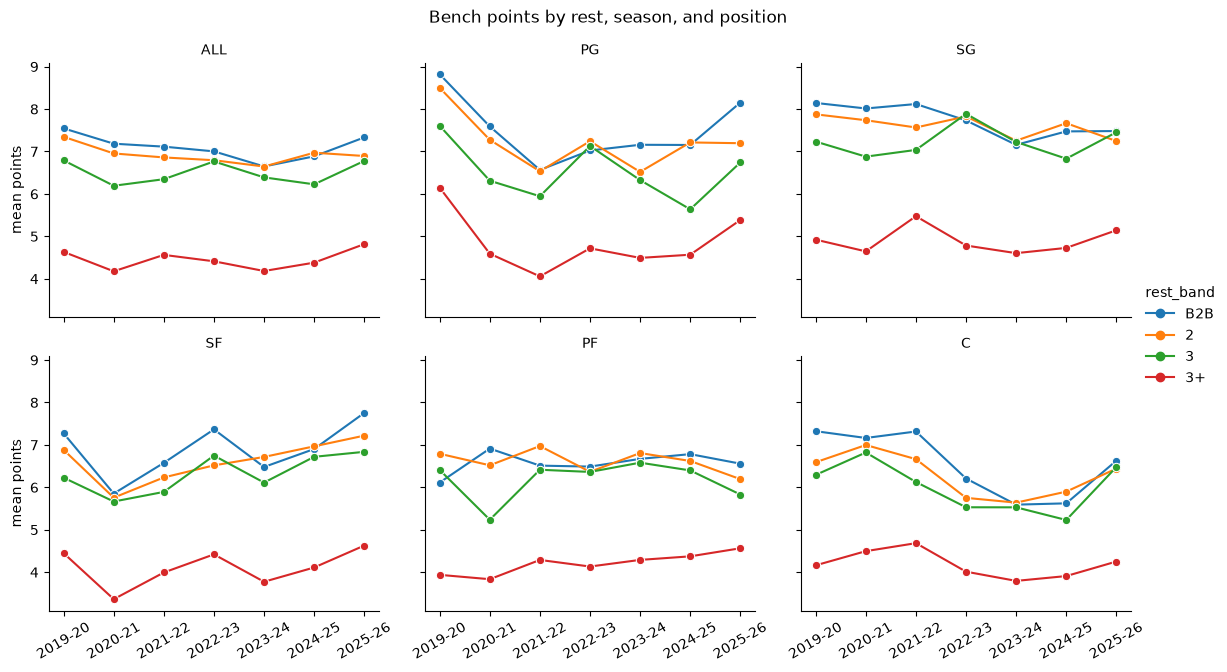

In [44]:
season_order = ["2019-20", "2020-21", "2021-22", "2022-23", "2023-24", "2024-25", "2025-26"]
bench_rest_year = bench_rest.assign(
    season_year=bench_rest["season_year"].astype("string"),
)
bench_rest_year = bench_rest_year.loc[
    bench_rest_year["season_year"].isin(season_order)
]

points_by_year_rest = (
    bench_rest_year.groupby(
        ["season_year", "pos", "rest_band"],
        observed=False,
    )["pts"]
    .mean()
    .reset_index(name="mean")
)
overall_by_year_rest = (
    bench_rest_year.groupby(["season_year", "rest_band"], observed=False)["pts"]
    .mean()
    .reset_index(name="mean")
    .assign(pos="ALL")
)
means = (
    overall_by_year_rest.pivot(index="season_year", columns="rest_band", values="mean")
    .reindex(index=season_order, columns=rest_order)
)
display(means.round(2))

plot = pd.concat([overall_by_year_rest, points_by_year_rest], ignore_index=True)
figure = sns.relplot(
    data=plot,
    x="season_year",
    y="mean",
    hue="rest_band",
    hue_order=rest_order,
    col="pos",
    col_order=["ALL", *pos_order],
    col_wrap=3,
    kind="line",
    marker="o",
    height=3.2,
    aspect=1.2,
)
figure.set_axis_labels("", "mean points")
figure.set_titles("{col_name}")
figure.figure.suptitle(
    "Bench points by rest, season, and position",
    y=1.03,
)
for ax in figure.axes.flatten():
    ax.tick_params(axis="x", rotation=30)
plt.show()


season_phase,before All-Star,after All-Star
pos,,
PG,6.60,6.94
SG,7.01,7.08
SF,6.06,6.11
PF,6.00,6.20
C,5.71,6.04


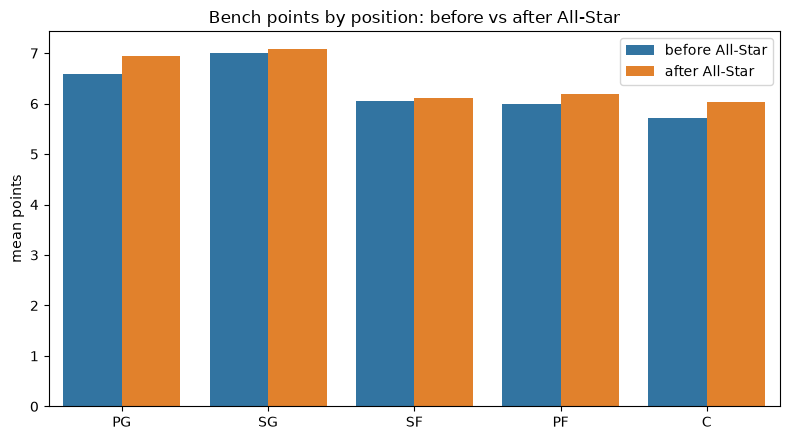

season_phase,before All-Star,after All-Star
rest_band,,
B2B,7.00,7.27
2,6.83,7.10
3,6.52,6.48
3+,4.32,4.68


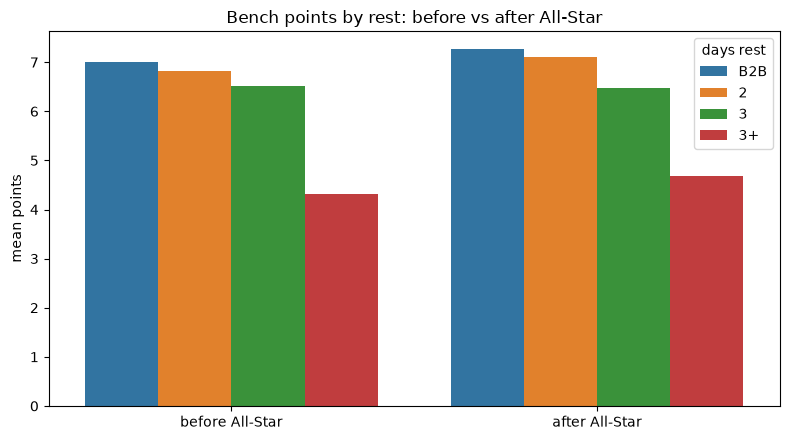

In [45]:
phase_order = ["before All-Star", "after All-Star"]
ALL_STAR_DATES = {
    "2019-20": pd.Timestamp("2020-02-16"),
    "2020-21": pd.Timestamp("2021-03-07"),
    "2021-22": pd.Timestamp("2022-02-20"),
    "2022-23": pd.Timestamp("2023-02-19"),
    "2023-24": pd.Timestamp("2024-02-18"),
    "2024-25": pd.Timestamp("2025-02-16"),
    "2025-26": pd.Timestamp("2026-02-15"),
}
game_date = pd.to_datetime(bench_rest["game_date"])
asb = bench_rest["season_year"].map(ALL_STAR_DATES)
bench_phase = bench_rest.assign(
    season_phase=np.select(
        [game_date.lt(asb), game_date.gt(asb)],
        phase_order,
        default="other",
    ),
)
bench_phase = bench_phase.loc[bench_phase["season_phase"].isin(phase_order)]

points_by_pos_phase = (
    bench_phase.groupby(["pos", "season_phase"], observed=False)["pts"]
    .agg(mean="mean", median="median", rows="size")
    .reset_index()
)
means_phase = (
    points_by_pos_phase.pivot(index="pos", columns="season_phase", values="mean")
    .reindex(index=pos_order, columns=phase_order)
)
display(means_phase.round(2))

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(
    data=points_by_pos_phase,
    x="pos",
    y="mean",
    hue="season_phase",
    order=pos_order,
    hue_order=phase_order,
    ax=ax,
)
ax.set_title("Bench points by position: before vs after All-Star")
ax.set_xlabel("")
ax.set_ylabel("mean points")
ax.legend(title="")
plt.tight_layout()
plt.show()

points_by_rest_phase = (
    bench_phase.groupby(["rest_band", "season_phase"], observed=False)["pts"]
    .mean()
    .reset_index(name="mean")
)
means_rest_phase = (
    points_by_rest_phase.pivot(index="rest_band", columns="season_phase", values="mean")
    .reindex(index=rest_order, columns=phase_order)
)
display(means_rest_phase.round(2))

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(
    data=points_by_rest_phase,
    x="season_phase",
    y="mean",
    hue="rest_band",
    order=phase_order,
    hue_order=rest_order,
    ax=ax,
)
ax.set_title("Bench points by rest: before vs after All-Star")
ax.set_xlabel("")
ax.set_ylabel("mean points")
ax.legend(title="days rest")
plt.tight_layout()
plt.show()
